# Using ABCMB with LINX

## Setup

In [1]:
import sys
sys.path.append('..')

from abcmb.main import Model

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

W0806 13:09:11.999743  191153 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0806 13:09:12.004642  190978 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


## LINX

ABCMB ships with LINX, a fully JAX Big Bang Nucleosynthesis (BBN) code.  This means you can tweak BBN model and nuisance parameters, compute the output $\textrm{YHe}$, and run that output through ABCMB to see the effects of BBN nuisance parameters on CMB physics.

This will involve new initialization parameters for our `Model`, and new parameters in our dictionary.

First, we set the `bbn_type` to `'LINX'`.  `Model` also as a field called `linx_reaction_net`, which specifies which BBN nuclear net to use.  By default we use a reduced version of the reaction network used in the 2023 version of the BBN code PRIMAT, but you can make other choices as well.  Let's use the reduced version of the network used in PArthENoPE:

In [2]:
model_LINX = Model(
    l_min = 2,
    l_max = 2500,
    lensing = True,    # Include lensing. This is False by default, so be sure to turn it on.
    bbn_type = "linx", # Set BBN computation to linx
    linx_reaction_net = "key_PArthENoPE" # Can select between 'key_PArthENoPE' and "key_PRIMAT_2023" (default) networks
)

/home/hector/NYU/ABCMB/example_notebooks/../abcmb/model_setup.py:163: UserWarning: DarkEnergy.rho could not be probed for the scalar contract (rho/P: scalar-in, scalar-out); it will only be checked by its first real use.
  _check_scalar_contract(instance)
/home/hector/NYU/ABCMB/example_notebooks/../abcmb/model_setup.py:163: UserWarning: DarkEnergy.P could not be probed for the scalar contract (rho/P: scalar-in, scalar-out); it will only be checked by its first real use.
  _check_scalar_contract(instance)
/home/hector/NYU/ABCMB/example_notebooks/../abcmb/model_setup.py:163: UserWarning: ColdDarkMatter.rho could not be probed for the scalar contract (rho/P: scalar-in, scalar-out); it will only be checked by its first real use.
  _check_scalar_contract(instance)
/home/hector/NYU/ABCMB/example_notebooks/../abcmb/model_setup.py:163: UserWarning: Baryon.rho could not be probed for the scalar contract (rho/P: scalar-in, scalar-out); it will only be checked by its first real use.
  _check_scal

We can then go ahead and specify some parameters--but there's a catch:

In [3]:
params_wrong = {
    'h': jnp.array(0.60), # hubble
    'omega_cdm': jnp.array(0.1293), # CDM density
    'omega_b': jnp.array(0.0216), # baryon density
    'Neff': jnp.array(3.5)
}

In [4]:
output_LINX = model_LINX(params_wrong)
ABC_tt_LINX = output_LINX.ClTT
ABC_te_LINX = output_LINX.ClTE
ABC_ee_LINX = output_LINX.ClEE
ABC_ell_LINX = output_LINX.l

ValueError: You have specified a value for N_nu_massless and/or Neff and/or T_nu_massless, but LINX instead expects 'Delta_Neff_init', which it uses to compute Neff. See the LINX docs or https://arxiv.org/abs/2408.14538.

LINX starts computing thermodynamic histories at very early times--before electron/positron annihilation.  Since the photon temperature has nontrivial evolution through the LINX solving region, it's very difficult to guess how much energy density one needs to add to their cosmology to get a desired $N_{\rm{eff}}$ by the end of BBN.

Therefore, LINX requires the user specify a parameter `Delta_Neff_init`, and does not let the user specify $N_{\rm{eff}}$.  `Delta_Neff_init` is $\Delta N_{\rm{eff}}$ at the beginning of BBN (10 MeV for the LINX initial conditions); it describes the energy density of an inert species that changes the expansion rate:
$$
\begin{equation}
\texttt{Delt\_Neff\_init} = \frac{8}{7}\left(\frac{11}{4}\right)^{4/3}\frac{\rho_{\textrm{extra},i}}{\rho_{\gamma,i}}
\end{equation}
$$
where $\rho_{\textrm{extra},i}$ is the energy density of the inert species.

See https://arxiv.org/abs/2408.14538 for more information.

In [5]:
params_right = {
    'h': jnp.array(0.60), # hubble
    'omega_cdm': jnp.array(0.1293), # CDM density
    'omega_b': jnp.array(0.0216), # baryon density
    'Delta_Neff_init': jnp.array(0.3)
}

`Model.add_derived_parameters` will store the corresponding `Neff` for us in addition to our input `Delta_Neff_init`.  Note a `Delta_Neff_init` of 0 corresponds to an `Neff` of 3.044.

In [6]:
# this cell will compile and run LINX to get the right Neff
derived_params_BBN = model_LINX.add_derived_parameters(params_right)
derived_params_BBN['Neff']

`\         /´  ||||        ||||  |||||     ||||  ||||   ||||
 /\_______/\   ||||        ||||  |||||||   ||||   |||| ||||
 ) __` ´__ (   ||||        ||||  |||| |||| ||||    |||||||
/  `-|_|-´  \  ||||        ||||  ||||  |||| |||    ||||||| 
/   (_x_)   \  ||||||||||  ||||  ||||   |||||||   |||| ||||
  )  `-´  (    ||||||||||  ||||  ||||    ||||||  ||||   ||||
 
Compiling thermodynamics model...


Compiling abundance model...


Array(3.12600995, dtype=float64)

In general, when performing parameter estimation in $\Lambda$CDM+$N_{\rm{eff}}$ cosmologies, it is recommended that you scan over values of `Delta_Neff_init`, and either save the corresponding $N_{\rm{eff}}$ as output or use LINX to construct an interpolation between your `Delta_Neff_init` samples and the desired output $N_{\rm{eff}}$ samples.

LINX can also accept an input from `params` specifying the values of BBN nuisance parameters, so that they can be sampled alongside other model parameters.  

`nuclear_rates_q` is an array of $q_i$, which scales the median values for measured reaction rates $\overline{r}_i$ according to $\log r_i (T) = \log \overline{r}_i (T) + q_i \sigma_i (T)$, where $r_i (T)$ is the rate that LINX will use for the specified reaction.  $q_i$ is a unit Gaussian random variable.  For more information, see [example notebooks on the LINX GitHub](http://localhost:8888/notebooks/Research/GitHub/LINX/example_notebooks/NuisanceParametersImpact.ipynb).

`tau_n_fac` is a multiplicative scaling of the neutron lifetime.  We choose a fiducial lifetime of 879.4s.

In [7]:
# there are 12 reactions in the LINX 'key' networks; include an array entry
# for each rate. 

params_nuisance = {
    'h': jnp.array(0.60),
    'omega_cdm': jnp.array(0.1293), 
    'omega_b': jnp.array(0.0216),
    'Delta_Neff_init': jnp.array(0.3),
    'nuclear_rates_q': jnp.array([1.0, 1.5, 0.0, 0.0, 1.0, 1.0, 0.0, -2.0, -1.5, 0., 0., 0.]),
    'tau_n_fac': jnp.array(1.2)
}

In [8]:
# this cell should not compile LINX since we already compiled it above for these dtypes
# and input sizes.  So it runs the (fast) cached compiled version.
params_nuisance_derived = model_LINX.add_derived_parameters(params_nuisance)
params_nuisance_derived["YHe"]

Array(0.2794586, dtype=float64)

In [9]:
# first evaluation will take a long time because
# the rest of ABCMB still needs to compile.
output = model_LINX(params_nuisance) # the model call derives parameters, then runs the traceable solve

l = output.l
ABC_tt = output.ClTT * l * (l+1) / 2 / jnp.pi
ABC_te = output.ClTE * l * (l+1) / 2 / jnp.pi
ABC_ee = output.ClEE * l * (l+1) / 2 / jnp.pi


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



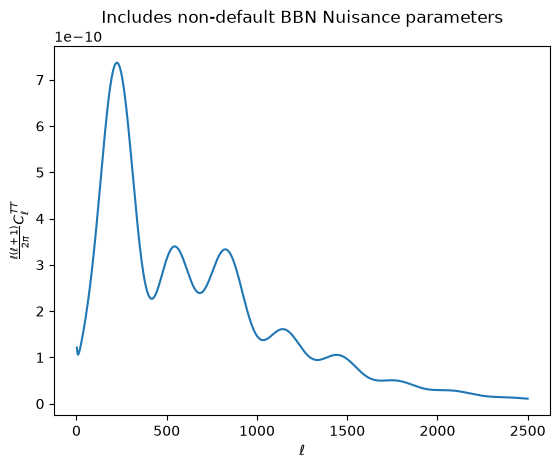

In [10]:
plt.plot(l, ABC_tt,label=r'$C_{\ell}^{TT}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}^{TT}$')
plt.title("Includes non-default BBN Nuisance parameters")
plt.show()